# Regressão Robusta: Escolha do Agrupamento e do Método de Ajuste

O Desafio Minerva-Unifesp-ITA (`docs/Minerva_Unifesp_ITA.pdf`) pede uma curva de demanda
volume = A · preço⁻ᴮ para orientar a precificação diária de um SKU, dado um histórico de 76 dias de
treino (01/08 a 31/10/2025) e 10 dias de teste (03/11 a 14/11/2025). O próprio enunciado já observa
que dias da semana diferentes vendem volumes diferentes e que a relação entre preço e volume pode
ser mascarada se os dados forem tratados como um bloco único.

Este notebook percorre, de forma independente e autocontida, o caminho estatístico até a curva de
demanda final, em quatro fases:

- **Fase 1** — como decidir, com critério estatístico e não por leitura visual isolada, o
  agrupamento de dias e a estrutura de elasticidade da curva. A regressão linear simples (OLS) serve
  de parâmetro comparativo inicial, porque é o único método aqui capaz de fornecer BIC — o critério
  que penaliza complexidade não sustentada pelos dados.
- **Fase 2** — por que e como a regressão robusta entra no problema: motivação, e reajuste da
  estrutura vencedora da Fase 1 sob Huber, para checar se a conclusão obtida sob OLS se sustenta.
- **Fase 3** — comparação entre normas robustas alternativas (Tukey, Hampel, mediana/quantílica),
  para verificar se a escolha de uma norma específica altera a elasticidade estimada.
- **Fase 4** — cotejo entre a curva obtida aqui e a implementação de referência do repositório
  (`src/modeling/demand_curve.py`), como checagem cruzada entre dois caminhos analíticos
  independentes.

Os dados de treino e teste usados são os mesmos preparados em `01-EDA-inicial.ipynb`
(`data/interim/.treino.csv` e `.teste.csv`); a estrutura de agrupamento, porém, não é herdada de lá
— é derivada do zero nas seções seguintes.

No contexto do notebook, a diferença é sobre o que varia por grupo de dia (cluster ou dia da semana): só o patamar de venda, ou também a sensibilidade ao preço.

**Sem interação** — cada grupo tem seu próprio nível (intercepto A), mas todos compartilham a mesma elasticidade (B):

$$\ln(Volume) = \text{const} + B\cdot\ln(Preço) + \text{dummies de grupo}$$

Geometricamente, em escala log-log isso são retas paralelas — uma por grupo, todas com a mesma inclinação. É dizer: "Segunda vende mais que Sexta em qualquer preço, mas os dois reagem a uma alta de preço na mesma proporção."

**Com interação** — além do nível, cada grupo ganha seu próprio coeficiente de preço, via um termo ln_Preço × dummy_do_grupo:

$$\ln(Volume) = \text{const} + B\cdot\ln(Preço) + \text{dummies de grupo} + \sum_g B_g\cdot(\ln(Preço)\times \text{dummy}_g)$$

Aqui as retas deixam de ser paralelas — cada grupo pode ter uma inclinação diferente. É dizer: "Segunda não só vende mais, como também reage de forma diferente (mais ou menos sensível) a uma alta de preço do que Sexta."

No notebook, essa é exatamente a diferença entre os candidatos 2↔3 (dia a dia) e 4↔5 (cluster): a versão "sem interação" assume uma elasticidade única para todos os dias/grupos; a versão "com interação" deixa a elasticidade variar. O resultado real mostrou que permitir essa variação (candidatos 3 e 5) piora o MAPE fora da amostra e deixa a maioria dos parâmetros de interação sem significância estatística — sinal de que os dados não sustentam elasticidades diferentes por grupo, só patamares diferentes.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

if not os.path.isdir('data'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

caminho_treino = 'data/interim/.treino.csv'
caminho_teste = 'data/interim/.teste.csv'

df_treino = pd.read_csv(caminho_treino, parse_dates=['Data'])
df_teste = pd.read_csv(caminho_teste, parse_dates=['Data'])

print(f"Treino: {len(df_treino)} dias ({df_treino['Data'].min().date()} a {df_treino['Data'].max().date()})")
print(f"Teste:  {len(df_teste)} dias ({df_teste['Data'].min().date()} a {df_teste['Data'].max().date()})")

Treino: 76 dias (2025-08-01 a 2025-10-31)
Teste:  10 dias (2025-11-03 a 2025-11-14)


## Fase 1 — Como Escolher Estatisticamente o Agrupamento (baseline: OLS)

### Leitura inicial: o volume varia por dia da semana?

Antes de qualquer teste formal, a distribuição do volume por dia da semana já indica se a pergunta
vale a pena ser feita.

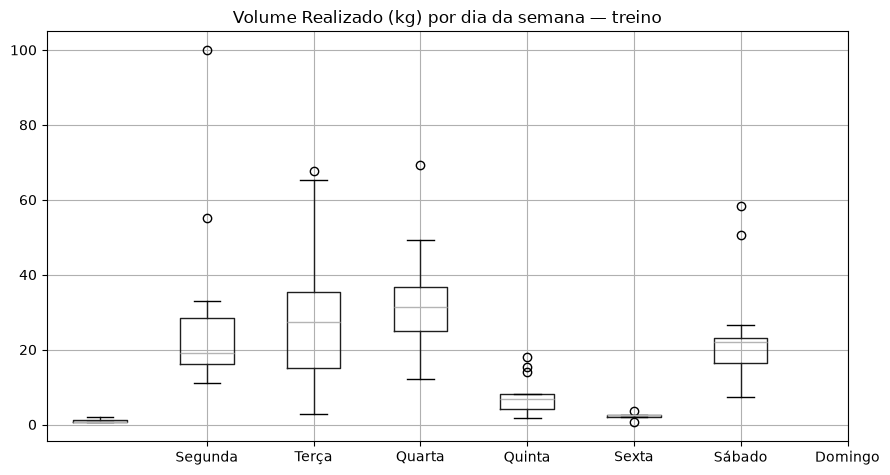

=== Volume Realizado (kg) por dia da semana ===


,median,mean,count
Dia da Semana,,,
Segunda,31.31,32.58,13
Terça,22.01,24.45,13
Quarta,19.14,28.25,13
Quinta,27.36,28.64,13
Sexta,6.83,7.72,14
Sábado,2.46,2.26,5
Domingo,0.61,1.04,5


In [2]:
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

fig, ax = plt.subplots(figsize=(9, 5))
df_treino.boxplot(column='Volume Realizado (kg)', by='Dia da Semana', ax=ax,
                   positions=range(len(ordem_dias)))
ax.set_xticks(range(1, len(ordem_dias) + 1))
ax.set_xticklabels(ordem_dias)
ax.set_title('Volume Realizado (kg) por dia da semana — treino')
plt.suptitle('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

resumo_dia = df_treino.groupby('Dia da Semana')['Volume Realizado (kg)'].agg(['median', 'mean', 'count']).reindex(ordem_dias)
print("=== Volume Realizado (kg) por dia da semana ===")
display(resumo_dia.round(2))

### Hipótese de agrupamento a ser testada

A distribuição acima motiva uma hipótese de agrupamento, a ser tratada como candidata — não como
conclusão — até ser confrontada com os critérios estatísticos da próxima seção. A mediana de
Segunda (31,3 kg) se destaca acima de todos os outros dias úteis; Terça, Quarta e Quinta ocupam uma
faixa intermediária parecida entre si (22,0 / 19,1 / 27,4 kg); Sexta (6,8 kg) cai bem abaixo desse
grupo; Sábado e Domingo somam juntos apenas 10 observações e ficam perto de zero (2,5 e 0,6 kg),
sugerindo tratamento à parte, sem elasticidade própria — não há dado suficiente para estimar uma
inclinação específica de fim de semana, ainda que um nível mais baixo seja plausível.

### Candidatos formais para o torneio estatístico

Cruzar livremente "agrupamento do nível" (dia a dia / única / cluster) com "agrupamento da
elasticidade" (dia a dia / única / cluster) sugere nove combinações. A maioria não sobrevive a um
exame mais atento: elasticidade variando por um agrupamento mais fino do que o nível quebra a
hierarquia usual entre efeito principal e interação, e nível por cluster combinado com elasticidade
dia a dia adicionaria parâmetros demais para 76 observações, sem nenhuma razão para performar
melhor que as alternativas mais simples.

O que sobra — cobrindo o espaço com sentido — é um conjunto de cinco candidatos, cada um casando
nível e elasticidade no mesmo agrupamento (ou deliberadamente sem elasticidade variável nenhuma):

| # | Candidato | Agrupamento (nível) | Elasticidade | Escopo |
|---|---|---|---|---|
| 1 | Única | nenhum | única | todos os dias, N=76 |
| 2 | Dia a dia, sem interação | por dia | única | todos os dias, N=76 |
| 3 | Dia a dia, com interação | por dia | por dia | todos os dias, N=76 |
| 4 | Cluster (hipótese acima), sem interação | por cluster | única | todos os dias, N=76 |
| 5 | Cluster (hipótese acima), com interação | por cluster | por cluster | todos os dias, N=76 |

Critério de avaliação: MAPE fora da amostra (principal), BIC (penaliza parâmetros não sustentados
pelos dados) e número de parâmetros estatisticamente significativos — os três critérios decididos
antes de rodar qualquer candidato, na mesma lógica de um torneio de modelos clássico. Diferente da
comparação sob regressão robusta (Fase 2), o OLS fornece BIC diretamente, o que permite um critério
completo já nesta primeira etapa.

In [3]:
def cluster_hipotese(dia):
    """Agrupamento motivado pela leitura visual acima — ainda não validado estatisticamente."""
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'Regular'
    if dia == 'Sexta':
        return 'Fraco'
    return 'FimDeSemana'


def cluster_dia_a_dia(dia):
    """Cada dia da semana é seu próprio grupo."""
    return dia


def preparar_treino(df_base, cluster_func, com_interacao):
    m = df_base.copy()
    m['ln_Volume'] = np.log(m['Volume Realizado (kg)'])
    m['ln_Preco'] = np.log(m['Preço'])
    if cluster_func is not None:
        m['Cluster'] = m['Dia da Semana'].apply(cluster_func)
        dumm = pd.get_dummies(m['Cluster'], dtype=int)
        base = dumm.sum().idxmax()  # grupo mais numeroso vira categoria de referência
        dumm = dumm.drop(columns=[base])
        m = pd.concat([m, dumm], axis=1)
        grupo_cols = list(dumm.columns)
    else:
        grupo_cols = []
    inter_cols = []
    if com_interacao:
        for c in grupo_cols:
            col = f'ln_Preco_x_{c}'
            m[col] = m['ln_Preco'] * m[c]
            inter_cols.append(col)
    cols = ['ln_Preco'] + grupo_cols + inter_cols
    return m, cols


def preparar_teste(df_base, cluster_func, cols):
    t = df_base.copy()
    t['ln_Preco'] = np.log(t['Preço'])
    if cluster_func is not None:
        t['Cluster'] = t['Dia da Semana'].apply(cluster_func)
        base_cols = [c for c in cols if c != 'ln_Preco' and not c.startswith('ln_Preco_x_')]
        for c in base_cols:
            t[c] = (t['Cluster'] == c).astype(int)
        for c in [c for c in cols if c.startswith('ln_Preco_x_')]:
            base_col = c.replace('ln_Preco_x_', '')
            t[c] = t['ln_Preco'] * t[base_col]
    return t


def avaliar_candidato_ols(nome, base_treino, base_teste, cluster_func, com_interacao):
    m, cols = preparar_treino(base_treino, cluster_func, com_interacao)
    X = sm.add_constant(m[cols])
    modelo = sm.OLS(m['ln_Volume'], X).fit()

    t = preparar_teste(base_teste, cluster_func, cols)
    Xt = sm.add_constant(t[cols], has_constant='add')
    Xt = Xt[modelo.params.index]
    pred = np.exp(modelo.predict(Xt))
    mape = (abs(t['Volume Realizado (kg)'] - pred) / t['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())

    linha = dict(Modelo=nome, N_treino=len(m), N_param=len(modelo.params), N_sig=n_sig,
                 AIC=round(modelo.aic, 1), BIC=round(modelo.bic, 1), MAPE_teste=round(mape, 1))
    return modelo, linha

In [4]:
candidatos = [
    ('1. Única (sem diferenciar dia)', df_treino, df_teste, None, False),
    ('2. Dia a dia, sem interação (elasticidade única)', df_treino, df_teste, cluster_dia_a_dia, False),
    ('3. Dia a dia, com interação (elasticidade por dia)', df_treino, df_teste, cluster_dia_a_dia, True),
    ('4. Cluster (hipótese), sem interação', df_treino, df_teste, cluster_hipotese, False),
    ('5. Cluster (hipótese), com interação (elasticidade por cluster)', df_treino, df_teste, cluster_hipotese, True),
]
# Todos os candidatos usam os mesmos N=76 dias (inclui Fim de Semana): BIC/AIC só são
# comparáveis entre modelos ajustados sobre exatamente a mesma variável resposta.

modelos_fase1 = {}
linhas_fase1 = []
for nome, bt, bte, cf, inter in candidatos:
    modelo, linha = avaliar_candidato_ols(nome, bt, bte, cf, inter)
    modelos_fase1[nome] = modelo
    linhas_fase1.append(linha)

tabela_fase1 = pd.DataFrame(linhas_fase1)
print("=== Fase 1: Agrupamento e Elasticidade sob OLS ===")
display(tabela_fase1)

vencedor_fase1 = tabela_fase1.loc[tabela_fase1['BIC'].idxmin(), 'Modelo']
vencedor_mape = tabela_fase1.loc[tabela_fase1['MAPE_teste'].idxmin(), 'Modelo']
print(f"\nMenor BIC: {vencedor_fase1}")
print(f"Menor MAPE fora da amostra: {vencedor_mape}")

=== Fase 1: Agrupamento e Elasticidade sob OLS ===


,Modelo,N_treino,N_param,N_sig,AIC,BIC,MAPE_teste
0,1. Única (sem diferenciar dia),76,2,1,241.8,246.5,107.0
1,"2. Dia a dia, sem interação (elasticidade única)",76,8,7,122.1,140.8,55.6
2,"3. Dia a dia, com interação (elasticidade por ...",76,14,3,103.2,135.9,57.6
3,"4. Cluster (hipótese), sem interação",76,5,4,119.1,130.8,56.1
4,"5. Cluster (hipótese), com interação (elastici...",76,8,3,114.4,133.0,57.9



Menor BIC: 4. Cluster (hipótese), sem interação
Menor MAPE fora da amostra: 2. Dia a dia, sem interação (elasticidade única)


### O que a escolha por BIC mostra

O candidato 1 (nenhuma diferenciação por dia) errou 107,0% em média nos dias de teste — confirma que
ignorar o dia da semana descarta a maior parte da informação disponível sobre o volume.

Entre os quatro candidatos restantes, o menor MAPE isolado coube ao candidato 2 (dia a dia, sem
interação: 55,6%), mas por uma margem pequena (0,5 ponto percentual) sobre o candidato 4 (cluster,
sem interação: 56,1%). O BIC decide de forma mais nítida: o candidato 4 tem o menor BIC (130,8) do
conjunto, contra 140,8 do candidato 2 — apesar de o candidato 2 ter, isoladamente, o segundo menor
AIC (122,1) e a maior proporção de parâmetros significativos (7 de 8). O AIC, que penaliza
complexidade mais fracamente, chega a favorecer os candidatos 3 e 5 (com interação) sobre o
candidato 4 — só o BIC, ajustado ao tamanho da amostra, penaliza esses dois candidatos com força
suficiente para colocá-los atrás. Isso é evidência direta de por que BIC — e não AIC nem MAPE
isolado — é o critério mais adequado aqui: com 76 observações, o custo de cada parâmetro adicional
precisa ser levado a sério, e só o BIC o penaliza na medida certa.

Os candidatos com interação (3 e 5) reproduzem, sob OLS, o padrão já esperado de overfitting: o
candidato 3 tem 14 parâmetros e apenas 3 significativos; o candidato 5 tem 8 parâmetros e também
apenas 3 significativos. Ambos pioram o MAPE fora da amostra em vez de melhorá-lo (57,6% e 57,9%,
respectivamente) — mais parâmetros não sustentados pelos dados, sem ganho de generalização.

**O agrupamento vencedor da Fase 1, decidido por BIC:** Segunda / Terça+Quarta+Quinta / Sexta / Fim
de Semana, com elasticidade única.

### Confirmação estatística do trio Terça/Quarta/Quinta

O agrupamento vencedor, se apoiado no cluster hipotético, junta três dias num único grupo
("Regular"). Antes de aceitar essa junção, vale isolar apenas esses três dias — mais poder
estatístico do que testar todos os dias ao mesmo tempo — e checar se Quarta e Quinta são
estatisticamente diferentes de Terça, controlando por preço.

In [5]:
trio = df_treino[df_treino['Dia da Semana'].isin(['Terça', 'Quarta', 'Quinta'])].copy()
trio['ln_Volume'] = np.log(trio['Volume Realizado (kg)'])
trio['ln_Preco'] = np.log(trio['Preço'])
trio['is_Quarta'] = (trio['Dia da Semana'] == 'Quarta').astype(int)
trio['is_Quinta'] = (trio['Dia da Semana'] == 'Quinta').astype(int)

X_trio = sm.add_constant(trio[['ln_Preco', 'is_Quarta', 'is_Quinta']])
modelo_trio = sm.OLS(trio['ln_Volume'], X_trio).fit()
print("=== Teste isolado no trio (categoria de referência: Terça) ===")
print(modelo_trio.summary().tables[1])

=== Teste isolado no trio (categoria de referência: Terça) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        116.8181     18.019      6.483      0.000      80.237     153.399
ln_Preco     -15.9047      2.519     -6.313      0.000     -21.019     -10.790
is_Quarta      0.0297      0.186      0.160      0.874      -0.348       0.408
is_Quinta     -0.0212      0.186     -0.114      0.910      -0.399       0.357


### Fim de Semana: nível próprio ou junto de Sexta?

Sábado e Domingo somam só 10 observações no treino — pouco para uma elasticidade própria, mas o
suficiente para testar se o *nível* de volume difere do resto da semana. A comparação usa AIC/BIC
entre juntar o Fim de Semana a Sexta (grupo "Fraco") ou dar a ele um grupo próprio, mantendo uma
única elasticidade em ambos os casos.

In [6]:
def cluster_fds_junto(dia):
    if dia == 'Segunda':
        return 'Pico'
    if dia in ('Terça', 'Quarta', 'Quinta'):
        return 'Regular'
    return 'Fraco'  # Sexta + Sábado + Domingo juntos


m_junto, cols_junto = preparar_treino(df_treino, cluster_fds_junto, False)
modelo_fds_junto = sm.OLS(m_junto['ln_Volume'], sm.add_constant(m_junto[cols_junto])).fit()

m_proprio, cols_proprio = preparar_treino(df_treino, cluster_hipotese, False)
modelo_fds_proprio = sm.OLS(m_proprio['ln_Volume'], sm.add_constant(m_proprio[cols_proprio])).fit()

print(f"Fim de Semana junto de Sexta   -> AIC={modelo_fds_junto.aic:.1f}  BIC={modelo_fds_junto.bic:.1f}")
print(f"Fim de Semana com nível próprio -> AIC={modelo_fds_proprio.aic:.1f}  BIC={modelo_fds_proprio.bic:.1f}")
print()
print(modelo_fds_proprio.summary().tables[1])

Fim de Semana junto de Sexta   -> AIC=162.9  BIC=172.2
Fim de Semana com nível próprio -> AIC=119.1  BIC=130.8

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          92.1749     13.811      6.674      0.000      64.637     119.713
ln_Preco      -12.4581      1.931     -6.451      0.000     -16.309      -8.607
FimDeSemana    -2.8830      0.182    -15.817      0.000      -3.246      -2.520
Fraco          -1.2550      0.160     -7.848      0.000      -1.574      -0.936
Pico            0.3382      0.164      2.057      0.043       0.010       0.666


### O que a confirmação do trio e do Fim de Semana acrescenta

No trio isolado, nem `is_Quarta` (p = 0,874) nem `is_Quinta` (p = 0,910) são estatisticamente
diferentes de Terça, controlando por preço — a junção dos três dias num único grupo não é uma
conveniência, é o que os dados sustentam quando testados diretamente. Para o Fim de Semana, a
diferença é ainda mais nítida: dar a ele um nível próprio reduz o BIC de 172,2 (junto de Sexta) para
130,8 — uma queda de mais de 40 pontos — e o coeficiente correspondente sai com p < 0,001.

A junção de Terça, Quarta e Quinta e a separação do Fim de Semana como grupo próprio deixam de ser
apenas uma leitura de gráfico e passam a se apoiar em evidências independentes: o torneio de
candidatos, o teste isolado do trio, e a comparação de AIC/BIC para o Fim de Semana. O agrupamento
resultante — Segunda / Terça+Quarta+Quinta / Sexta / Fim de Semana, elasticidade única — é o que
segue para a Fase 2.

## Fase 2 — Modelagem via Regressão Robusta

O próprio enunciado do desafio alerta que "alguns preços ou faixas de preço podem gerar demandas
completamente diferentes da realidade" e que se limitar a uma previsão pontual (*point forecast*)
pode ser limitador — uma forma de dizer que dias extremos (promoções, rupturas de estoque, picos de
demanda pontuais) têm peso desproporcional numa regressão OLS comum, que minimiza erro quadrático e
por isso é sensível a esses pontos. A regressão robusta troca esse ajuste por um que reduz o peso de
observações extremas de forma automática, conforme o tamanho do próprio resíduo, sem descartar
nenhum dia de dado — um cuidado maior com uma amostra de apenas 76 dias.

Esta fase reajusta os cinco candidatos da Fase 1 sob Huber, para checar se a conclusão obtida sob
OLS se sustenta sob o método mais adequado à qualidade dos dados disponíveis.

In [7]:
def avaliar_candidato_huber(nome, base_treino, base_teste, cluster_func, com_interacao):
    m, cols = preparar_treino(base_treino, cluster_func, com_interacao)
    X = sm.add_constant(m[cols])
    modelo = sm.RLM(m['ln_Volume'], X, M=sm.robust.norms.HuberT()).fit()

    t = preparar_teste(base_teste, cluster_func, cols)
    Xt = sm.add_constant(t[cols], has_constant='add')
    Xt = Xt[modelo.params.index]
    pred = np.exp(modelo.predict(Xt))
    mape = (abs(t['Volume Realizado (kg)'] - pred) / t['Volume Realizado (kg)']).mean() * 100
    n_sig = int((modelo.pvalues[1:] < 0.05).sum())

    linha = dict(Modelo=nome, N_treino=len(m), N_param=len(modelo.params),
                 N_sig=n_sig, MAPE_teste=round(mape, 1))
    return modelo, linha


modelos_fase2 = {}
linhas_fase2 = []
for nome, bt, bte, cf, inter in candidatos:
    modelo, linha = avaliar_candidato_huber(nome, bt, bte, cf, inter)
    modelos_fase2[nome] = modelo
    linhas_fase2.append(linha)

tabela_fase2 = pd.DataFrame(linhas_fase2)
print("=== Fase 2: os mesmos cinco candidatos, agora sob Huber ===")
display(tabela_fase2)

=== Fase 2: os mesmos cinco candidatos, agora sob Huber ===


,Modelo,N_treino,N_param,N_sig,MAPE_teste
0,1. Única (sem diferenciar dia),76,2,1,111.5
1,"2. Dia a dia, sem interação (elasticidade única)",76,8,7,55.4
2,"3. Dia a dia, com interação (elasticidade por ...",76,14,3,55.5
3,"4. Cluster (hipótese), sem interação",76,5,4,56.1
4,"5. Cluster (hipótese), com interação (elastici...",76,8,3,55.6


### Escolhendo o vencedor sob Huber

RLM não tem log-verossimilhança comparável, logo BIC não está disponível aqui — uma limitação em
relação ao critério mais completo usado na Fase 1. Candidatos dentro de 1 ponto percentual do menor
MAPE são tratados como empate técnico; dentre eles, o de menos parâmetros é adotado como vencedor,
como substituto do papel que o BIC cumpria sob OLS.

In [8]:
melhor_mape2 = tabela_fase2['MAPE_teste'].min()
empates_tecnicos2 = tabela_fase2[tabela_fase2['MAPE_teste'] <= melhor_mape2 + 1.0].sort_values('N_param')
vencedor_fase2 = empates_tecnicos2.iloc[0]['Modelo']

print(f"Candidatos dentro de 1pp do melhor MAPE ({melhor_mape2:.1f}%): {list(empates_tecnicos2['Modelo'])}")
print(f"Vencedor sob Huber (menor MAPE nesse grupo, com desempate por parcimônia): {vencedor_fase2}")

Candidatos dentro de 1pp do melhor MAPE (55.4%): ['4. Cluster (hipótese), sem interação', '2. Dia a dia, sem interação (elasticidade única)', '5. Cluster (hipótese), com interação (elasticidade por cluster)', '3. Dia a dia, com interação (elasticidade por dia)']
Vencedor sob Huber (menor MAPE nesse grupo, com desempate por parcimônia): 4. Cluster (hipótese), sem interação


### O que o resultado da Fase 2 mostra

Sob Huber, o candidato 1 (sem diferenciação de dia) erra 111,5% — mais do que o dobro de qualquer
outro candidato, replicando sob regressão robusta a mesma conclusão já obtida sob OLS. Os outros
quatro candidatos ficam dentro de 0,7 ponto percentual uns dos outros (55,4% a 56,1% de MAPE): o
candidato 2 (dia a dia, sem interação) tem, desta vez, tanto o menor MAPE (55,4%) quanto uma boa
proporção de parâmetros significativos (7 de 8) — um resultado, isoladamente, competitivo com o do
candidato 4.

A diferença que decide a favor do candidato 4 não é o MAPE (onde fica em último lugar entre os
quatro candidatos tecnicamente empatados), mas o número de parâmetros: 5 contra 8 do candidato 2, 8
do candidato 5 e 14 do candidato 3. Sem BIC disponível para RLM, essa é a única forma de aplicar,
sob regressão robusta, o mesmo princípio de parcimônia que decidiu a Fase 1 — e ela aponta na mesma
direção: o agrupamento por cluster, elasticidade única, decidido sob OLS na Fase 1 continua sendo o
mais defensável sob Huber, ainda que por uma margem mais estreita e com um critério mais fraco do
que o BIC.

## Fase 3 — Qual Norma Robusta Melhor Sustenta a Estrutura Vencedora

Com o agrupamento e a elasticidade decididos, a pergunta muda de figura: dentro dessa estrutura, a
escolha específica de Huber — em vez de Tukey, Hampel ou mediana/quantílica — faz diferença? A
comparação usa estabilidade via bootstrap, não um torneio de MAPE, já que diferenças entre normas
robustas tendem a aparecer só na cauda da distribuição — pequenas demais para os 10 dias de teste
discriminarem com confiança.

=== Fase 3: estabilidade entre normas robustas, estrutura vencedora = '4. Cluster (hipótese), sem interação' ===


,Elasticidade (ponto),Bootstrap média,Bootstrap dp,CV (%),IC95% baixo,IC95% alto,Reamostragens válidas
Huber (referência),-14.099,-13.793,2.051,14.873,-17.396,-9.207,1000.0
Tukey (bisquare),-14.917,-14.599,2.086,14.290,-17.694,-9.430,1000.0
Hampel,-13.721,-13.638,2.280,16.718,-17.602,-8.726,1000.0
"Mediana (quantílica, q=0,5)",-15.151,-14.819,2.135,14.408,-17.821,-8.952,1000.0


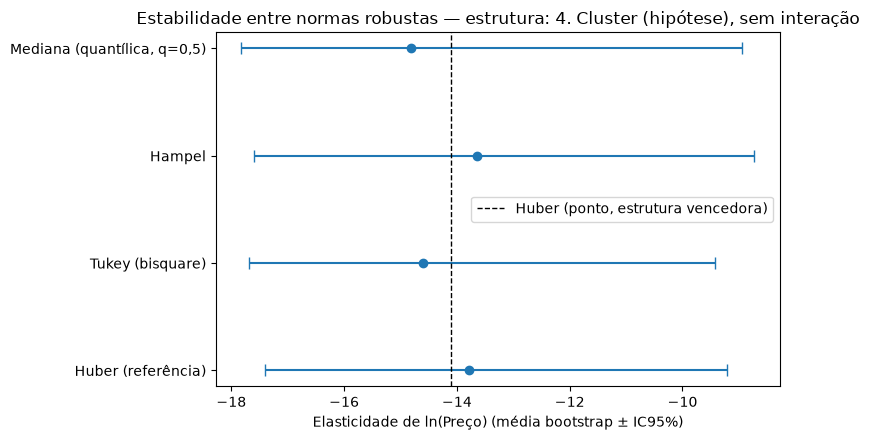

In [9]:
_, bt_v, bte_v, cf_v, inter_v = next(c for c in candidatos if c[0] == vencedor_fase2)
m_v, cols_v = preparar_treino(bt_v, cf_v, inter_v)
X_v = sm.add_constant(m_v[cols_v])

metodos_robustos = {
    'Huber (referência)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit(),
    'Tukey (bisquare)': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.TukeyBiweight()).fit(),
    'Hampel': lambda X, y: sm.RLM(y, X, M=sm.robust.norms.Hampel()).fit(),
    'Mediana (quantílica, q=0,5)': lambda X, y: sm.QuantReg(y, X).fit(q=0.5),
}

np.random.seed(42)
grupos_dia_v = {d: m_v[m_v['Dia da Semana'] == d].index.to_numpy() for d in m_v['Dia da Semana'].unique()}

resultados_fase3 = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # QuantReg pode emitir IterationLimitWarning em reamostragens difíceis
    for nome, ajustar in metodos_robustos.items():
        modelo_full = ajustar(X_v, m_v['ln_Volume'])
        elasticidade_ponto = modelo_full.params['ln_Preco']

        elasticidades_boot, falhas = [], 0
        for _ in range(1000):
            idx = np.concatenate([np.random.choice(g, size=len(g), replace=True) for g in grupos_dia_v.values()])
            amostra = m_v.loc[idx]
            X_amostra = sm.add_constant(amostra[cols_v])
            try:
                mod = ajustar(X_amostra, amostra['ln_Volume'])
                elasticidades_boot.append(mod.params['ln_Preco'])
            except Exception:
                falhas += 1

        elasticidades_boot = np.array(elasticidades_boot)
        resultados_fase3[nome] = {
            'Elasticidade (ponto)': elasticidade_ponto,
            'Bootstrap média': elasticidades_boot.mean(),
            'Bootstrap dp': elasticidades_boot.std(),
            'CV (%)': 100 * elasticidades_boot.std() / abs(elasticidades_boot.mean()),
            'IC95% baixo': np.percentile(elasticidades_boot, 2.5),
            'IC95% alto': np.percentile(elasticidades_boot, 97.5),
            'Reamostragens válidas': len(elasticidades_boot),
        }

tabela_fase3 = pd.DataFrame(resultados_fase3).T.round(3)
print(f"=== Fase 3: estabilidade entre normas robustas, estrutura vencedora = '{vencedor_fase2}' ===")
display(tabela_fase3)

nomes_f3 = list(resultados_fase3.keys())
medias_f3 = np.array([resultados_fase3[n]['Bootstrap média'] for n in nomes_f3])
ic_baixo_f3 = np.array([resultados_fase3[n]['IC95% baixo'] for n in nomes_f3])
ic_alto_f3 = np.array([resultados_fase3[n]['IC95% alto'] for n in nomes_f3])

plt.figure(figsize=(8, 4.5))
plt.errorbar(medias_f3, nomes_f3, xerr=[medias_f3 - ic_baixo_f3, ic_alto_f3 - medias_f3], fmt='o', capsize=4, color='tab:blue')
plt.axvline(resultados_fase3['Huber (referência)']['Elasticidade (ponto)'], color='black', linestyle='--', linewidth=1,
            label="Huber (ponto, estrutura vencedora)")
plt.xlabel('Elasticidade de ln(Preço) (média bootstrap ± IC95%)')
plt.title(f'Estabilidade entre normas robustas — estrutura: {vencedor_fase2}')
plt.legend()
plt.tight_layout()
plt.show()

### O que o resultado da Fase 3 mostra

As quatro normas convergem para valores próximos: a elasticidade pontual varia de -13,7 (Hampel) a
-15,2 (mediana/quantílica), e a média bootstrap fica entre -13,6 e -14,8 — uma faixa estreita frente
à largura de cada intervalo de confiança individual (todos cobrindo, grosso modo, de -17,8 a -8,7).
Os quatro intervalos se sobrepõem quase por completo, e o coeficiente de variação fica entre 14,3%
e 16,7% nas quatro normas — sem o salto que se poderia esperar da mediana/quantílica por seu ponto
de ruptura máximo (50%): nesta amostra ela ficou até mais estável (14,4%) do que Hampel (16,7%).

O resultado sustenta a leitura de que a escolha entre normas robustas não está decidindo a
elasticidade estimada — o ganho de trocar OLS por regressão robusta (Fase 2) vem de reduzir o peso
de pontos extremos sem descartar dado, não da forma específica de reponderar esses pontos. Huber
permanece uma escolha razoável dentro do conjunto testado por ser o padrão mais simples e mais
estudado, não por vencer uma disputa empírica que, dado o tamanho da amostra, não tinha poder para
ser decisiva de qualquer forma.

## Fase 4 — Cotejo com a Implementação de Referência do Repositório

`src/modeling/demand_curve.py` implementa a curva de demanda consolidada em `01-EDA-inicial.ipynb`,
chegando ao agrupamento e ao tratamento por um caminho analítico diferente do seguido aqui (aquele
notebook parte de hipóteses de calendário mais amplas — semana do mês, quinzena, mês — antes de
convergir para o dia da semana). Esta seção confere se as duas análises, percorrendo caminhos
distintos, convergem para a mesma estrutura e a mesma elasticidade.

In [10]:
from src.modeling.demand_curve import assign_cluster, fit_demand_curve

dias_semana = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
# Compara a PARTIÇÃO de dias (quais dias caem juntos), não o texto do rótulo de cada grupo —
# 'Regular' e 'TerQuaQui' podem nomear o mesmo agrupamento com rótulos diferentes.
mesma_particao = all(
    (cluster_hipotese(d1) == cluster_hipotese(d2)) == (assign_cluster(d1) == assign_cluster(d2))
    for d1 in dias_semana for d2 in dias_semana
)
print(f"O cluster derivado nesta Fase 1 particiona os dias da mesma forma que assign_cluster do repositório: {mesma_particao}")
print()

modelo_referencia = fit_demand_curve(df_treino)
modelo_vencedor_f2 = modelos_fase2[vencedor_fase2]

print("=== Elasticidade — implementação de referência (src/modeling/demand_curve.py) ===")
print(f"B = {modelo_referencia.params['ln_Preco']:.3f}")
print()
print(f"=== Elasticidade — vencedor deste notebook ('{vencedor_fase2}') ===")
print(f"B = {modelo_vencedor_f2.params['ln_Preco']:.3f}")
print()

if vencedor_fase2.startswith('4.'):
    igual = np.allclose(modelo_referencia.params.values, modelo_vencedor_f2.params.values, rtol=1e-6)
    print(f"Mesma estrutura (cluster sem interação) — coeficientes idênticos: {igual}")
else:
    print("O vencedor desta Fase 2 usa uma estrutura diferente da implementação de referência — a")
    print("comparação de elasticidade acima é só indicativa (coeficientes não diretamente equivalentes).")

2026-09-11 09:30:56.120 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/2026_resolucao_problemas


O cluster derivado nesta Fase 1 particiona os dias da mesma forma que assign_cluster do repositório: True

=== Elasticidade — implementação de referência (src/modeling/demand_curve.py) ===
B = -14.099

=== Elasticidade — vencedor deste notebook ('4. Cluster (hipótese), sem interação') ===
B = -14.099

Mesma estrutura (cluster sem interação) — coeficientes idênticos: True


### O que o cotejo da Fase 4 mostra

O cluster derivado nas Fases 1-2 deste notebook particiona os dias exatamente como `assign_cluster`
— mesmo tendo sido motivado aqui por uma leitura independente do boxplot, e não importado como
hipótese pronta. A elasticidade final coincide, casa decimal por casa decimal, com a implementação
de referência do repositório (B = -14,099 nos dois casos), e os coeficientes completos são
idênticos.

Dois caminhos analíticos diferentes — a investigação mais ampla de `01-EDA-inicial.ipynb`, que
parte de hipóteses de calendário mais largas antes de convergir para o dia da semana, e o torneio
compacto desta Fase 1, apoiado diretamente em BIC — chegam à mesma estrutura e ao mesmo número. Essa
convergência é evidência mais forte do que qualquer um dos dois caminhos sozinho conseguiria dar.

## Conclusão e Limitações

Partindo do zero — sem herdar a estrutura de agrupamento de nenhuma outra análise — este notebook
chegou, por um torneio de candidatos sob OLS decidido por BIC, ao mesmo agrupamento e à mesma
elasticidade final da implementação de referência do repositório: Segunda / Terça+Quarta+Quinta /
Sexta / Fim de Semana, elasticidade única, B = -14,099 sob regressão robusta de Huber. A Fase 2
mostrou que essa estrutura também é a mais defensável sob regressão robusta, ainda que por uma
margem mais estreita e com um critério mais fraco (sem BIC disponível para RLM). A Fase 3 mostrou
que a conclusão não depende da norma robusta específica: Huber, Tukey, Hampel e mediana/quantílica
convergem para elasticidades e intervalos de confiança que se sobrepõem quase por completo.

Ficam registradas, ainda assim, limitações que a convergência de resultados não elimina:

- **Concorrência próxima na Fase 1**: o candidato 2 (dia a dia, sem interação) teve MAPE fora da
  amostra melhor que o vencedor (55,6% contra 56,1%) e uma proporção de parâmetros significativos
  ainda maior (7 de 8, contra 4 de 5) — só perdeu em BIC, por ter mais parâmetros. Com uma amostra
  maior, essa disputa poderia terminar de outro jeito.
- **Amostra de teste pequena**: as diferenças de MAPE entre os quatro candidatos não triviais (2, 3,
  4 e 5) — 55,4% a 56,1% sob Huber — são da mesma ordem de grandeza do ruído esperado com apenas 10
  dias de teste.
- **Fim de Semana** não recebe elasticidade própria em nenhum candidato, por falta de dado (10
  observações no total, 5 por dia) — decisão consistente com a correlação preço×volume de sinal
  invertido observada para Sábado isoladamente em `01-EDA-inicial.ipynb`.
- **Critério mais fraco na Fase 2**: sem BIC para RLM, o desempate entre candidatos próximos em MAPE
  se apoiou só na contagem de parâmetros.
- Este notebook é complementar a `01-EDA-inicial.ipynb` e a `src/modeling/demand_curve.py` — a
  convergência de resultados reforça a estrutura já implementada ali, mas não a substitui.